# 1.Сформулировать постановку задачу, которую хочется решать в рамках курса.

Сформулирована бизнес-постановка задачи (например, реализовать спам/не спам детектор) - 3 балла

Сформулирована постановка ML-задачи (бинарная классификация) - 2 балла

Представлен набор данных, достаточный для решения поставленной задачи - 3 балла

## 1.1 Сформулирована бизнес-постановка задачи (например, реализовать спам/не спам детектор) - 3 балла


*Оптимизация успеваемости учащихся в средней школе*

Выявить, какие демографические, социальные и другие характеристики имеют наибольшее влияние на успеваемость и итоговые оценки учащихся. На основе этих данных можно разработать программы поддержки, направленные на улучшение успеваемости, такие как дополнительные занятия, консультации или изменения в учебных планах.

## 1.2 Сформулирована постановка ML-задачи - 2 балла


*Прогнозирование итоговой оценки учащихся на основе других атрибутов*

Тип задачи - регрессия

## 1.3 Представлен набор данных, достаточный для решения поставленной задачи - 3 балла

[Эти данные ](https://www.kaggle.com/datasets/dipam7/student-grade-prediction)отражают успеваемость учащихся в средней школе двух португальских школ. Атрибуты данных включают оценки учащихся, демографические, социальные и школьные характеристики) и были собраны с использованием школьных отчетов и анкет. Предоставляются два набора данных об успеваемости по двум различным предметам: математика (mat) и португальский язык (por). Два набора данных были смоделированы с помощью задач бинарной/пятиуровневой классификации и регрессии

Используя атрибуты, такие как G1, G2, возраст, образование родителей, время на учебу, количество пропусков и другие, необходимо построить модель, которая будет предсказывать итоговую оценку G3. Модель должна учитывать, что G3 является итоговой оценкой и сильно коррелирует с G1 и G2, **но цель состоит в том, чтобы предсказать G3 без использования G1 и G2, что сделает задачу более сложной и интересной.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Фтми/2 курс/ОП и ПМО/student-mat.csv')

# 2. Выбрать и обосновать метрику для измерения качества.

В рамках данного пункта необходимо подобрать наиболее релевантную метрику или набор метрик для вашей задачи, написав краткое обоснование (1-2 предложения).

Предложена метрика - 3 балла

Присутствует корректное обоснование - 5 баллов

Выбранная метрика - Средняя абсолютная ошибка

Средняя абсолютная ошибка измеряет среднее значение абсолютных ошибок между предсказанными и фактическими значениями итоговой оценки G3. MAE является хорошей метрикой для задач регрессии, так как она дает представление о том, **насколько близко предсказанные значения находятся к реальным значениям**.
Эта метрика выбрана, так как она обеспечивает **устойчивость к выбросам**, поскольку все ошибки взвешиваются одинаково. Также **легко сравнивать производительность** разных моделей.

Это важно **в контексте образовательных оценок,** где как недооценка, так и переоценка могут иметь серьезные последствия.



# 3. Провести EDA на своих данных

В рамках данного пункта необходимо провести предварительный разведочный анализ своего набора данных.

Критерии оценки:

Рассмотрены базовые характеристики/статистики для набора данных - 3 балла

Реализованы наиболее релевантные визуализации - 5 баллов

По ходу работы присутствуют комментарии (вы, как эксперт в предметной области, можете проинтерпретировать полученные результаты анализа, визуализации, расcчитанные статистики, сделав выводы о том, каким образом лучше работать с набором данных в будущем, какие могут возникнуть проблемы, какую предобработку целесообразно сделать и тп). - 6 баллов

Предполагается, что студенты среди прочего продемонстрируют использование библиотек для визуализации, рассматриваемых в курсе (seaborn, plotly).

## 3.1 Базовые характеристики/статистики для набора данных

### Тип данных каждого столбца и описание атрибутов

In [4]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


Описание каждого атрибута:

school - школа ученика (двоичный код: 'GP' - Габриэль Перейра или 'MS' - Мусиньо да Силвейра)

sex — пол студента (двоичный код: «Ж» — женский или «М» — мужской)

age - возраст ученика (числовой: от 15 до 22)

address - тип домашнего адреса студента (двоичный: 'U' - городской или 'R' - сельский)

famsize — размер семейства (двоичный: «LE3» — меньше или равно 3 или «GT3» — больше 3)

Pstatus — статус совместного проживания родителей (двоичный код: «Т» — проживание вместе или «А» — раздельно)

Medu  — образование матери (числовое: 0 — нет, 1 — начальное образование (4 класс), 2 — с 5 по 9 классы, 3 — среднее образование или 4 — высшее образование)

Fedu  — образование отца (числовое: 0 — нет, 1 — начальное образование (4 класс), 2 — с 5 по 9 классы, 3 — среднее образование или 4 — высшее образование)

Mjob - работа матери (номинал: «учитель», «связанный со здравоохранением», гражданские «службы» (например, административные или полицейские), «на дому» или «другое»)

Fjob - работа отца (номинал: «учитель», «связанный со здравоохранением», гражданские «службы» (например, административные или полицейские), «на дому» или «другое»)

reason  - причина выбрать эту школу (номинал: близок к «дому», «репутация» школы, предпочтение «курса» или «другое»)

guardian  - опекун ученика (номинальное: «мать», «отец» или «другой»)

traveltime — время в пути домой в школу (числовое: 1 – <15 минут, 2 – 15 – 30 минут, 3 – 30 минут до 1 часа или 4 – >1 часа)

Studytime — еженедельное время обучения (числовое: 1 — <2 часов, 2 — 2–5 часов, 3 — 5–10 часов или 4 — >10 часов)

failures  - количество прошлых сбоев класса (числовое: n, если 1<=n<3, иначе 4)

schoolsup  - дополнительная образовательная поддержка (бинарный: да или нет)

famsup — образовательная поддержка семьи (бинарный: да или нет)

paid  — дополнительные платные занятия по предмету курса (математика или португальский язык) (бинарный: да или нет)

activities  – внеклассные мероприятия (бинарный: да или нет)

nursery - посещал детский сад (бинарный: да или нет)

higher  – хочет получить высшее образование (бинарный: да или нет)

Internet — доступ в Интернет дома (бинарный: да или нет)

romantic  – состоит ли в отношениях (бинарный: да или нет)

famrel - качество семейных отношений (числовое: от 1 - очень плохо до 5 -
отлично)

freetime – свободное время после школы (числовое: от 1 – очень низкое до 5 – очень высокое)

goout – встреча с друзьями (числовое: от 1 – очень низкий до 5 – очень высокий)

Dalc - потребление алкоголя в течение рабочего дня (числовое: от 1 - очень низкое до 5 - очень высокое)

Walc – потребление алкоголя в выходные дни (числовое: от 1 – очень низкое до 5 – очень высокое)
здоровье – текущее состояние здоровья (числовое: от 1 – очень плохое до 5 – очень хорошее)

absences - количество пропусков в школе (числовое: от 0 до 93)
эти оценки связаны с предметом курса (математика или португальский язык):

G1 – оценка за первый период (числовая: от 0 до 20)

G2 – оценка за второй период (числовая: от 0 до 20)

G3 — итоговая оценка (числовая: от 0 до 20, выходная цель)

### Проверка на нулевые значения

In [5]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


### Матрица корреляций

Отражает наиболее сильные и слабые взаимосвязи между каждой парой переменных

Как и предполагалось, Модель должна учитывать, что G3 является итоговой оценкой и сильно коррелирует с G1 и G2, **но цель состоит в том, чтобы предсказать G3 без использования G1 и G2, что сделает задачу более сложной и интересной.**.Предсказать G3 без G2 и G1 сложнее, но такой прогноз гораздо полезнее.

                 age      Medu      Fedu  traveltime  studytime  failures  \
age         1.000000 -0.163658 -0.163438    0.070641  -0.004140  0.243665   
Medu       -0.163658  1.000000  0.623455   -0.171639   0.064944 -0.236680   
Fedu       -0.163438  0.623455  1.000000   -0.158194  -0.009175 -0.250408   
traveltime  0.070641 -0.171639 -0.158194    1.000000  -0.100909  0.092239   
studytime  -0.004140  0.064944 -0.009175   -0.100909   1.000000 -0.173563   
failures    0.243665 -0.236680 -0.250408    0.092239  -0.173563  1.000000   
famrel      0.053940 -0.003914 -0.001370   -0.016808   0.039731 -0.044337   
freetime    0.016434  0.030891 -0.012846   -0.017025  -0.143198  0.091987   
goout       0.126964  0.064094  0.043105    0.028540  -0.063904  0.124561   
Dalc        0.131125  0.019834  0.002386    0.138325  -0.196019  0.136047   
Walc        0.117276 -0.047123 -0.012631    0.134116  -0.253785  0.141962   
health     -0.062187 -0.046878  0.014742    0.007501  -0.075616  0.065827   

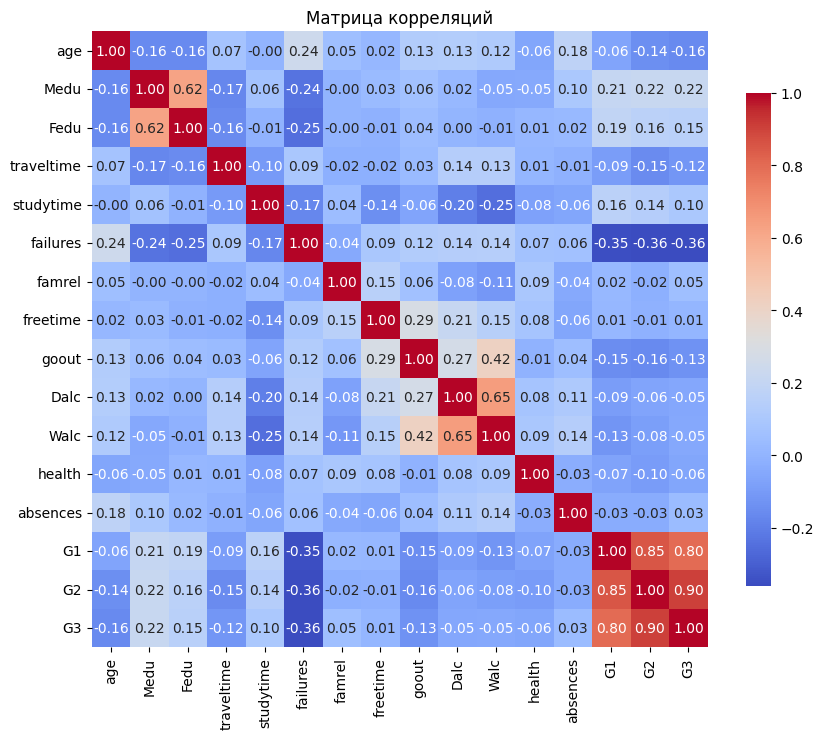

In [6]:
# Исключение нечисловых столбцов
numeric_df = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_df.corr()
print(correlation_matrix)

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций')
plt.show()

Так, наибольшее влияние, кроме промежуточных оценок, имеют образование матери и отца, еженедельное время обучения, качество семейных отнощений, пропуски и количество свободного времени

## 3.2 Наиболее релевантные визуализации

Для указанных атрибутов создадим визуализации

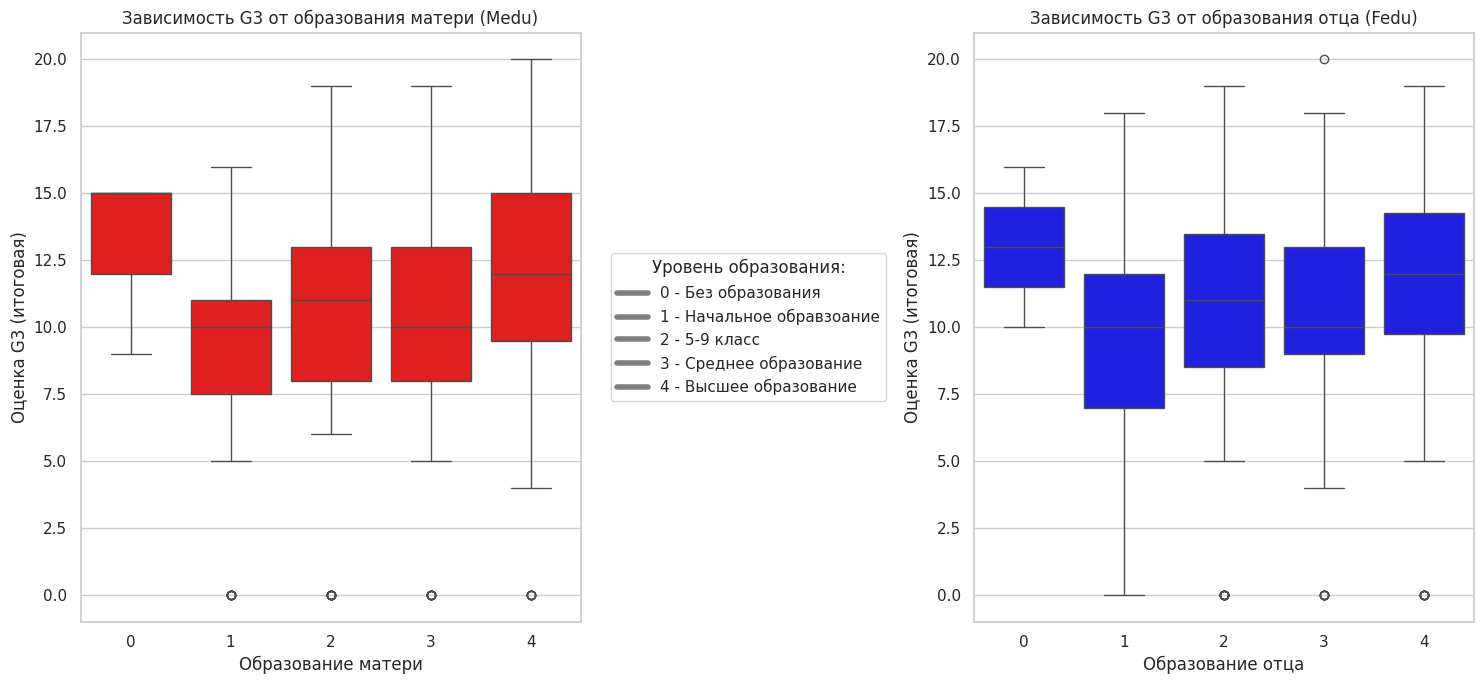

In [7]:
sns.set(style="whitegrid")

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.boxplot(x='Medu', y='G3', data=df, ax=axes[0], color='red')
axes[0].set_title('Зависимость G3 от образования матери (Medu)')
axes[0].set_xlabel('Образование матери')
axes[0].set_ylabel('Оценка G3 (итоговая)')

sns.boxplot(x='Fedu', y='G3', data=df, ax=axes[1], color='blue')
axes[1].set_title('Зависимость G3 от образования отца (Fedu)')
axes[1].set_xlabel('Образование отца')
axes[1].set_ylabel('Оценка G3 (итоговая)')

# метки на осях от 0 до 4
axes[0].set_xticks(range(5))
axes[1].set_xticks(range(5))

legend_labels = {
0: 'Без образования',
1: 'Начальное образование',
2: '5–9 класс',
3: 'Среднее образование',
4: 'Высшее образование'
}

# Добавляем общую легенду
handles = [
plt.Line2D([0], [0], color='grey', lw=4, label='0 - Без образования'),
plt.Line2D([0], [0], color='grey', lw=4, label='1 - Начальное обравзоание'),
plt.Line2D([0], [0], color='grey', lw=4, label='2 - 5-9 класс'),
plt.Line2D([0], [0], color='grey', lw=4, label='3 - Среднее образование'),
plt.Line2D([0], [0], color='grey', lw=4, label='4 - Высшее образование')
]
plt.legend(handles=handles, loc='center', bbox_to_anchor=(-0.45, 0.5), title="Уровень образования:")

# Настройка общего оформления
plt.tight_layout()
plt.show()

Инетерсно, что дети, где один из родителей не имеет образования, судя по результатам, получают оценки выше (видимо, мотивации больше)

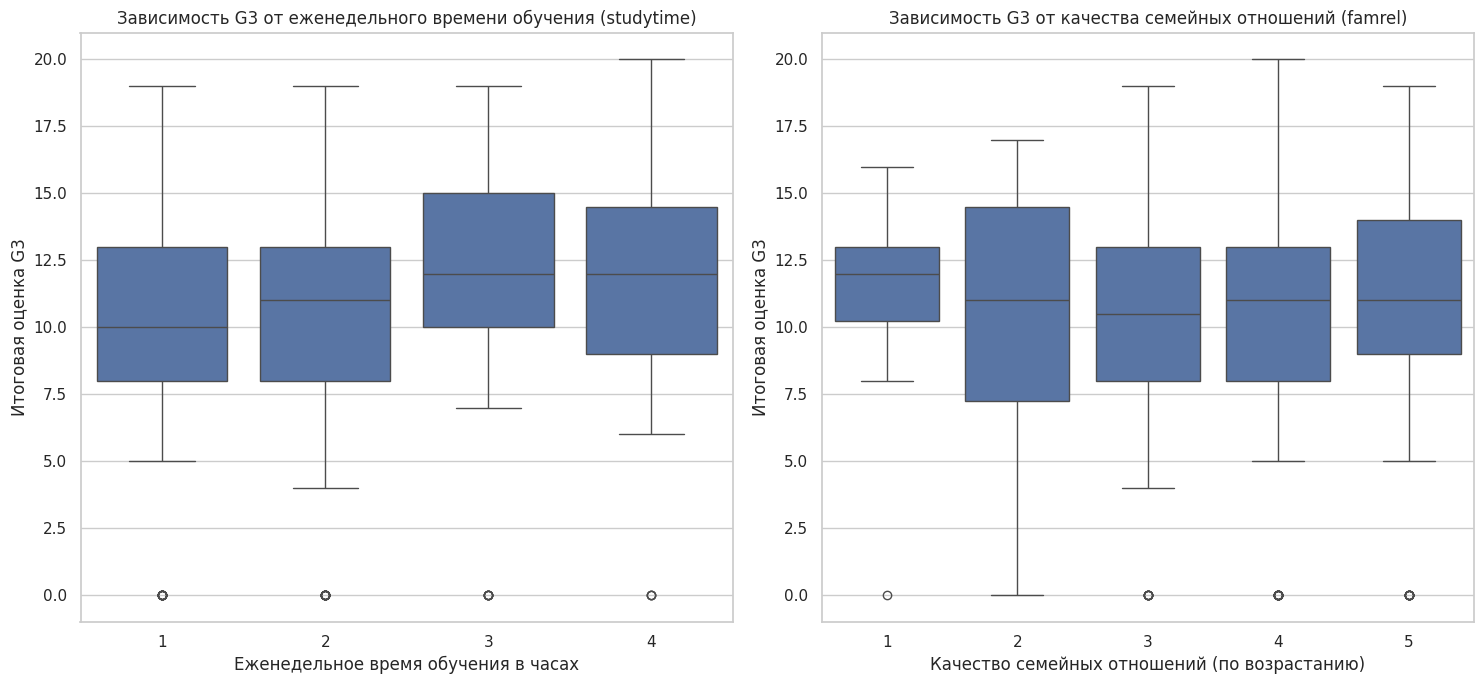

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Визуализация зависимости G3 от studytime
sns.boxplot(x='studytime', y='G3', data=df, ax=axes[0])
axes[0].set_title('Зависимость G3 от еженедельного времени обучения (studytime)')
axes[0].set_xlabel('Еженедельное время обучения в часах') # Подпись оси X
axes[0].set_ylabel('Итоговая оценка G3') # Подпись оси Y

# Визуализация зависимости G3 от famrel
sns.boxplot(x='famrel', y='G3', data=df, ax=axes[1])
axes[1].set_title('Зависимость G3 от качества семейных отношений (famrel)')
axes[1].set_xlabel('Качество семейных отношений (по возрастанию)') # Подпись оси X
axes[1].set_ylabel('Итоговая оценка G3') # Подпись оси Y

# Настройка общего оформления
plt.tight_layout()
plt.show()

Некоторые другие визуализации

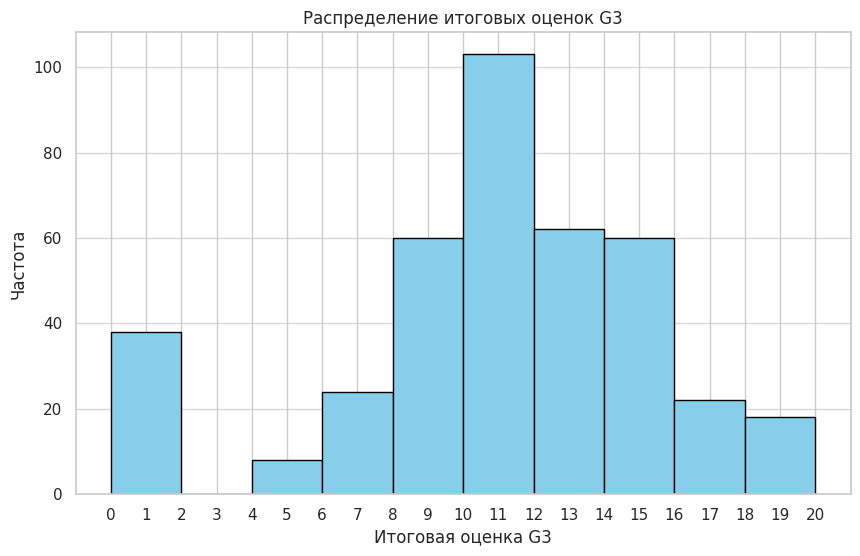

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black') # Используем гистограмму для распределения
plt.title('Распределение итоговых оценок G3')
plt.xlabel('Итоговая оценка G3')
plt.ylabel('Частота')
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.75)
plt.show()

Распределение нормальное (действительно, в общей массе ученики имеют средние результаты) с выбросом в сторону плохих оценок, поэтому можем объединить оценки в группы.  

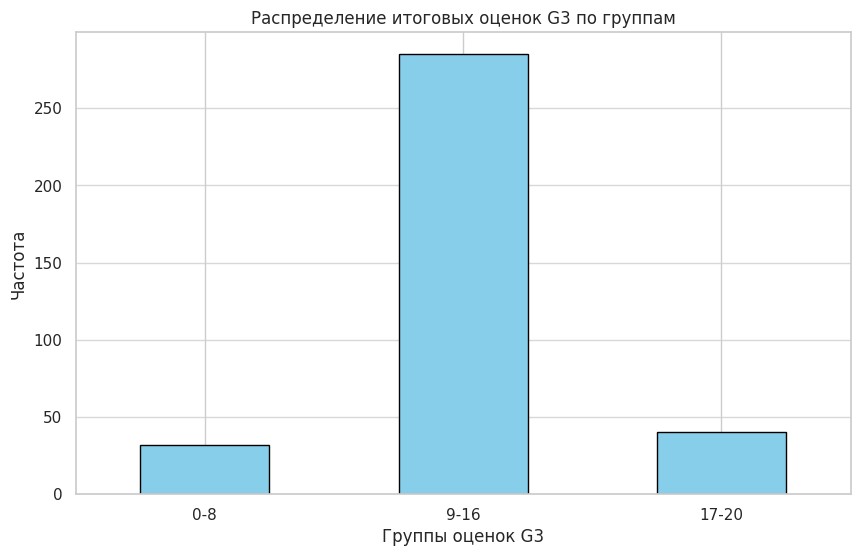

In [13]:
bins = [0, 7, 15, 20]
labels = ['0-8', '9-16', '17-20']

# Создаем новую колонку с группами
df['G3_group'] = pd.cut(df['G3'], bins=bins, labels=labels, right=True)

# Создаем столбиковую диаграмму для распределения групп G3
plt.figure(figsize=(10, 6))
df['G3_group'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение итоговых оценок G3 по группам')
plt.xlabel('Группы оценок G3')
plt.ylabel('Частота')
plt.xticks(rotation=0) # Убираем наклон меток на оси X
plt.grid(axis='y', alpha=0.75)
plt.show()

Кстати, вот обзор школьной системы оценок

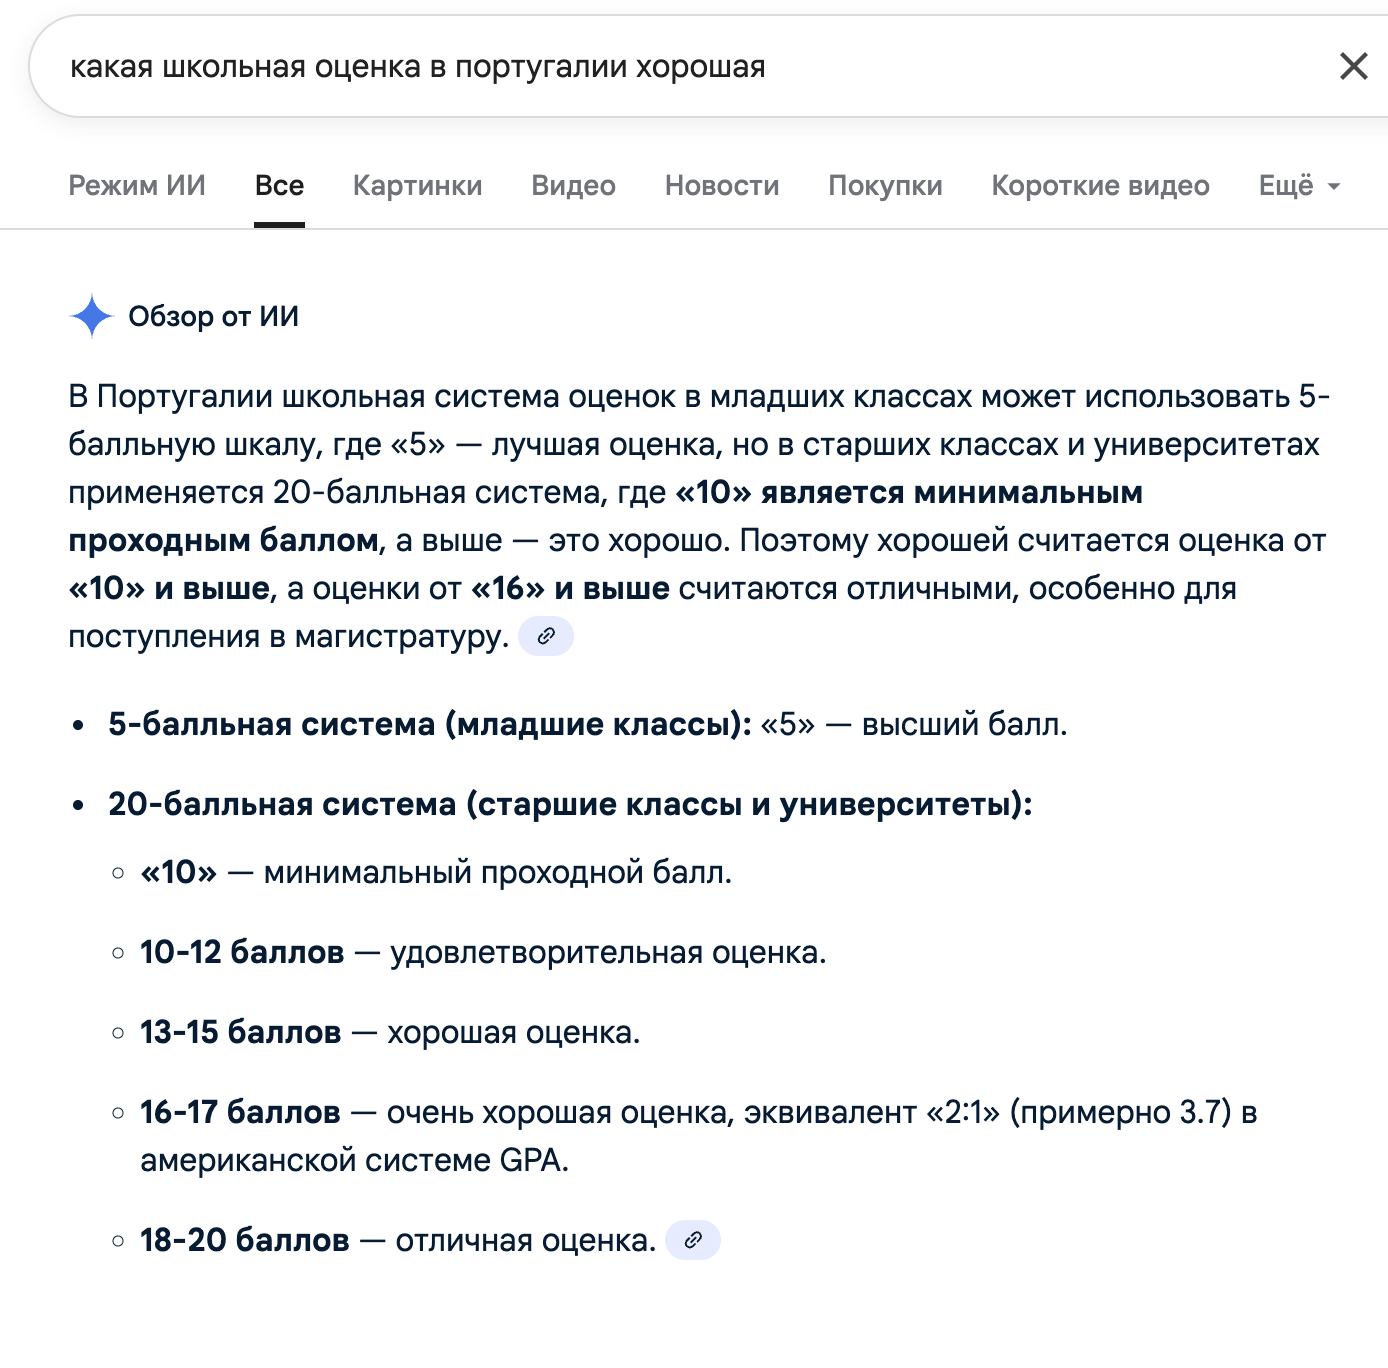

Для промежуточных оценок визуализируем с помошью круговой диаграммы

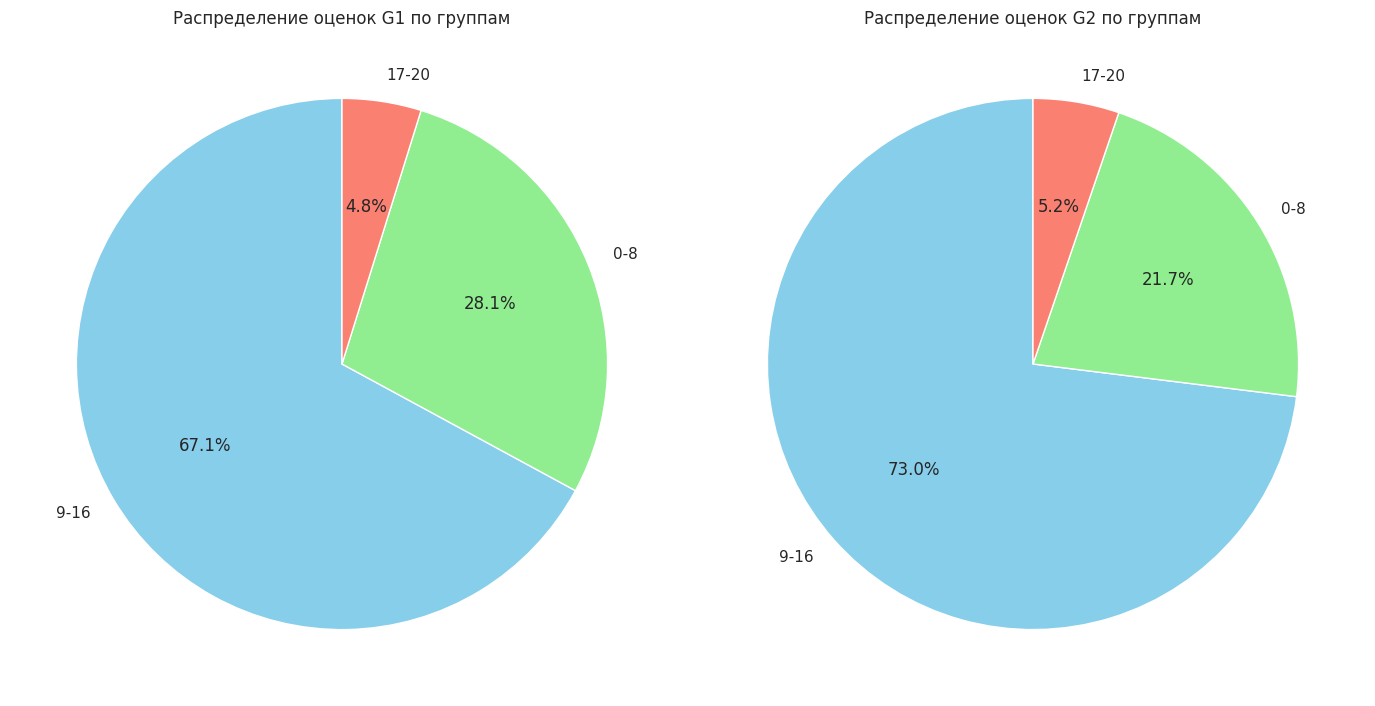

In [14]:
bins = [0, 8, 16, 20]
labels = ['0-8', '9-16', '17-20']

# Создаем новые колонки с группами для G1 и G2
df['G1_group'] = pd.cut(df['G1'], bins=bins, labels=labels, right=True)
df['G2_group'] = pd.cut(df['G2'], bins=bins, labels=labels, right=True)

# Подсчитываем частоту для каждой группы по G1 и G2
g1_counts = df['G1_group'].value_counts()
g2_counts = df['G2_group'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Круговая диаграмма для G1
axes[0].pie(g1_counts, labels=g1_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon'])
axes[0].set_title('Распределение оценок G1 по группам')

# Круговая диаграмма для G2
axes[1].pie(g2_counts, labels=g2_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon'])
axes[1].set_title('Распределение оценок G2 по группам')

# Отображаем диаграммы
plt.tight_layout()
plt.show()

и для G3 тогда

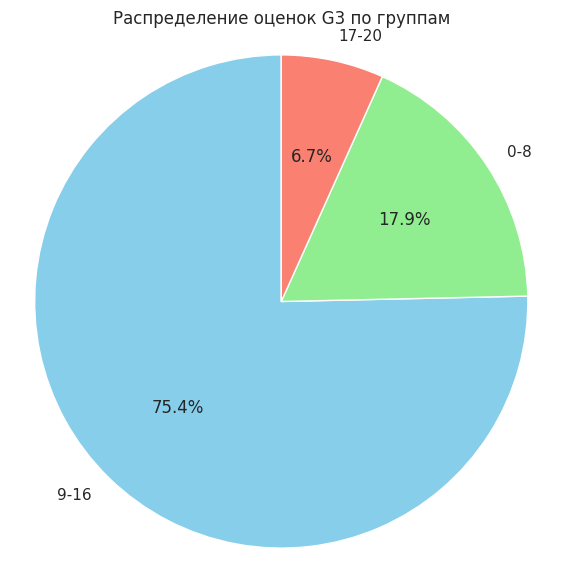

In [15]:
bins = [0, 8, 16, 20]
labels = ['0-8', '9-16', '17-20']

# Создаем новую колонку с группами для G3
df['G3_group'] = pd.cut(df['G3'], bins=bins, labels=labels, right=True)

# Подсчитываем частоту для каждой группы по G3
g3_counts = df['G3_group'].value_counts()

# Создаем фигуру для круговой диаграммы
plt.figure(figsize=(7, 7))

# Круговая диаграмма для G3
plt.pie(g3_counts, labels=g3_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Распределение оценок G3 по группам')

# Отображаем диаграмму
plt.axis('equal') # Чтобы круговая диаграмма была кругом
plt.show()

Но для сравнения хорошо подойдет линейный график, тоже по группам

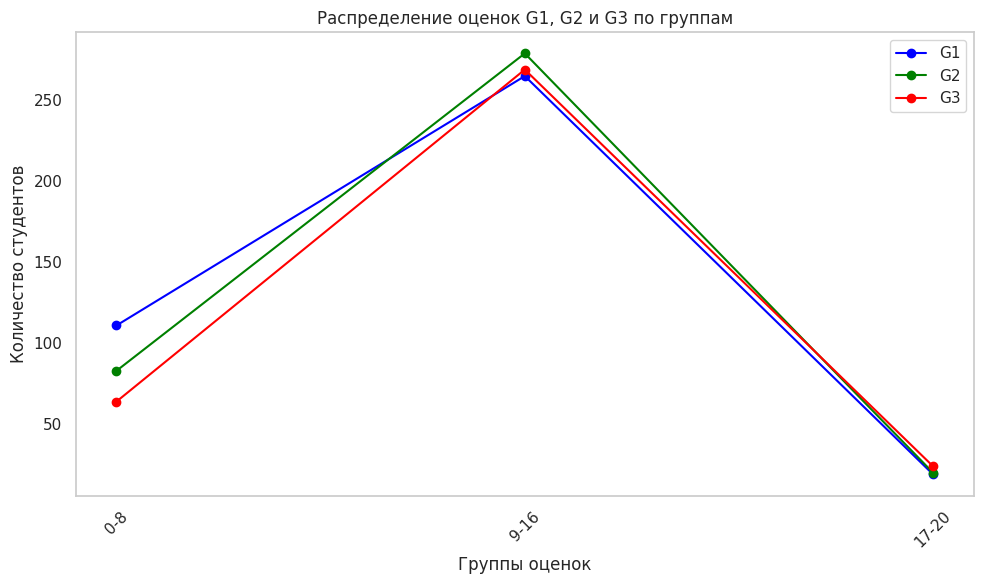

In [16]:
bins = [0, 8, 16, 20]
labels = ['0-8', '9-16', '17-20']

# Создаем новые колонки с группами для G1, G2 и G3
df['G1_group'] = pd.cut(df['G1'], bins=bins, labels=labels, right=True)
df['G2_group'] = pd.cut(df['G2'], bins=bins, labels=labels, right=True)
df['G3_group'] = pd.cut(df['G3'], bins=bins, labels=labels, right=True)

# Подсчитываем частоту для каждой группы по G1, G2 и G3
g1_counts = df['G1_group'].value_counts().sort_index()
g2_counts = df['G2_group'].value_counts().sort_index()
g3_counts = df['G3_group'].value_counts().sort_index()

# Создаем DataFrame для удобного отображения
grouped_data = pd.DataFrame({
'G1': g1_counts,
'G2': g2_counts,
'G3': g3_counts
})

# Создаем линейный график
plt.figure(figsize=(10, 6))
plt.plot(grouped_data.index, grouped_data['G1'], marker='o', label='G1', color='blue')
plt.plot(grouped_data.index, grouped_data['G2'], marker='o', label='G2', color='green')
plt.plot(grouped_data.index, grouped_data['G3'], marker='o', label='G3', color='red')

# Настройка графика
plt.title('Распределение оценок G1, G2 и G3 по группам')
plt.xlabel('Группы оценок')
plt.ylabel('Количество студентов')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

# Отображаем график
plt.tight_layout()
plt.show()

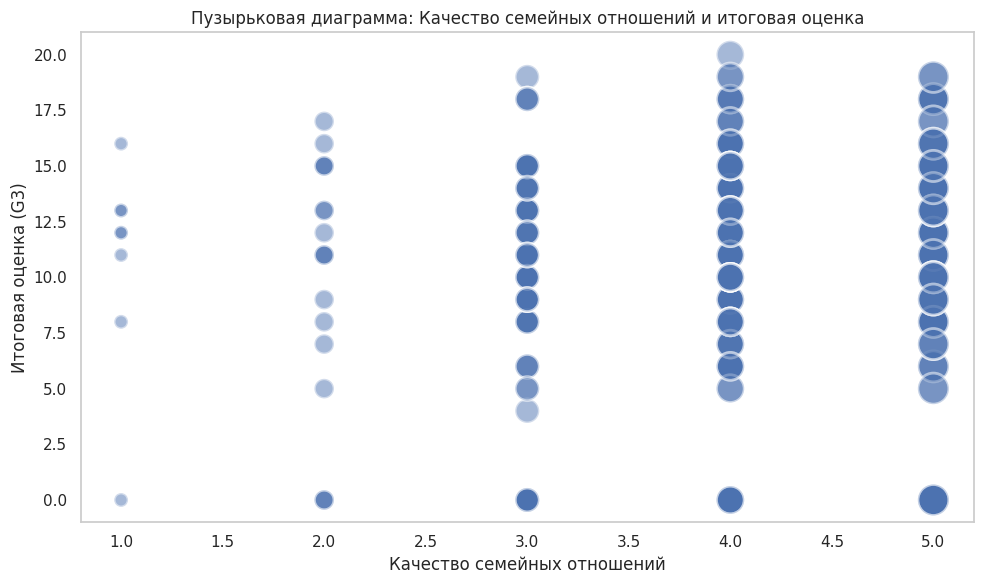

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(df['famrel'], df['G3'],
s=df['famrel']*100, # Размер пузырьков
alpha=0.5, edgecolors="w", linewidth=2)

# Настройка графика
plt.title('Пузырьковая диаграмма: Качество семейных отношений и итоговая оценка')
plt.xlabel('Качество семейных отношений')
plt.ylabel('Итоговая оценка (G3)')
plt.grid()

# Отображаем график
plt.tight_layout()
plt.show()

Эта визуализация подтверждает, что корреляция слабая. очевидной зависимости нет, включать этот атрибут в модель, скорее всего, не имеет смысла

#4. О будущем и подготовка к следующей лабораторной

Так как корреляции между итоговой оценкой G3 и другими атрибутами не самые сильные, за исключением промежуточных оценок G1 и G2, то в следубщей работе будем строить модель предсказания на основе этих оценок, а через лабораторную попробуем работать с образованием родителей, еженедельным временем обучения и качеством семейных отношений. Возможно, эти атрибуты и будут изменены.